<a href="https://colab.research.google.com/github/acnoori/CE5331/blob/main/SW_Development_Coordination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coordination in Software Development

This educational notebook simulates and visualizes the coordination game in software development described in **MIT OpenCourseWare (Chapter 8: Further Applications)**.

## 1. Game Formulation

Consider $n$ software developers, indexed by $i = 1, 2, \dots, n$. Each developer $i$ has an **ideal specification** $\theta_i \in \mathbb{R}$. Simultaneously, each developer chooses an actual specification parameter $s_i \in \mathbb{R}$.

The payoff function for player $i$ is:

$$u_i(s_1, \dots, s_n) = 100 - (s_i - \theta_i)^2 - \frac{1}{n-1} \sum_{j \neq i} (s_i - s_j)^2$$

### Interpretation of Costs:
1. **Inherent Cost**: $(s_i - \theta_i)^2$ — the cost of deviating from their own ideal specification.
2. **Incompatibility Cost**: $\frac{1}{n-1} \sum_{j \neq i} (s_i - s_j)^2$ — the average cost of being incompatible with other developers' final product specifications.

---

## 2. Analytical Nash Equilibrium

To find the Best Response of player $i$, we take the first-order condition (FOC) with respect to $s_i$:

$$\frac{\partial u_i}{\partial s_i} = -2(s_i - \theta_i) - \frac{2}{n-1} \sum_{j \neq i} (s_i - s_j) = 0$$

This simplifies to:

$$2s_i = \theta_i + \frac{1}{n-1} \sum_{j \neq i} s_j$$

By summing this best response equation over all $i$, we can solve the system of equations to obtain the unique Nash Equilibrium strategy $s_i^*$ for each developer:

$$s_i^* = \frac{n-1}{2n-1} \theta_i + \frac{1}{2n-1} \sum_{j=1}^n \theta_j$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

def compute_nash_equilibrium(theta):
    """
    Computes the Nash Equilibrium specifications given an array of ideal specifications theta.
    """
    n = len(theta)
    sum_theta = np.sum(theta)

    # Analytical formula: s_i = [(n-1)/(2n-1)] * theta_i + [1/(2n-1)] * sum(theta_j)
    s_star = ((n - 1) / (2 * n - 1)) * theta + (1 / (2 * n - 1)) * sum_theta
    return s_star

## 3. Simulation & Visualizations

Let's simulate a scenario with $n = 7$ developers, each having randomly assigned ideal specifications $\theta_i$, and observe how they compromise to reach coordination.

In [2]:
# Seed for reproducibility
np.random.seed(42)

n_developers = 7
developers = [f"Dev {i+1}" for i in range(n_developers)]
# Generate random ideal specifications between 10 and 90
theta = np.sort(np.random.uniform(10, 90, n_developers))

# Compute Nash Equilibrium specifications
s_star = compute_nash_equilibrium(theta)

# Create a DataFrame for representation
df = pd.DataFrame({
    'Developer': developers,
    'Ideal Spec (theta_i)': theta,
    'Equilibrium Spec (s_i*)': s_star
})

display(df)

,Developer,Ideal Spec (theta_i),Equilibrium Spec (s_i*)
0,Dev 1,14.646689,30.766186
1,Dev 2,22.479562,34.381358
2,Dev 3,22.481491,34.382249
3,Dev 4,39.963210,42.450734
4,Dev 5,57.892679,50.725874
5,Dev 6,68.559515,55.649029
6,Dev 7,86.057145,63.724858


### Plotting the Compromise: Ideal vs. Equilibrium Specifications
The plot below illustrates how developers' final specifications ($s_i^*$) shrink toward the group average relative to their original ideal points ($\theta_i$).

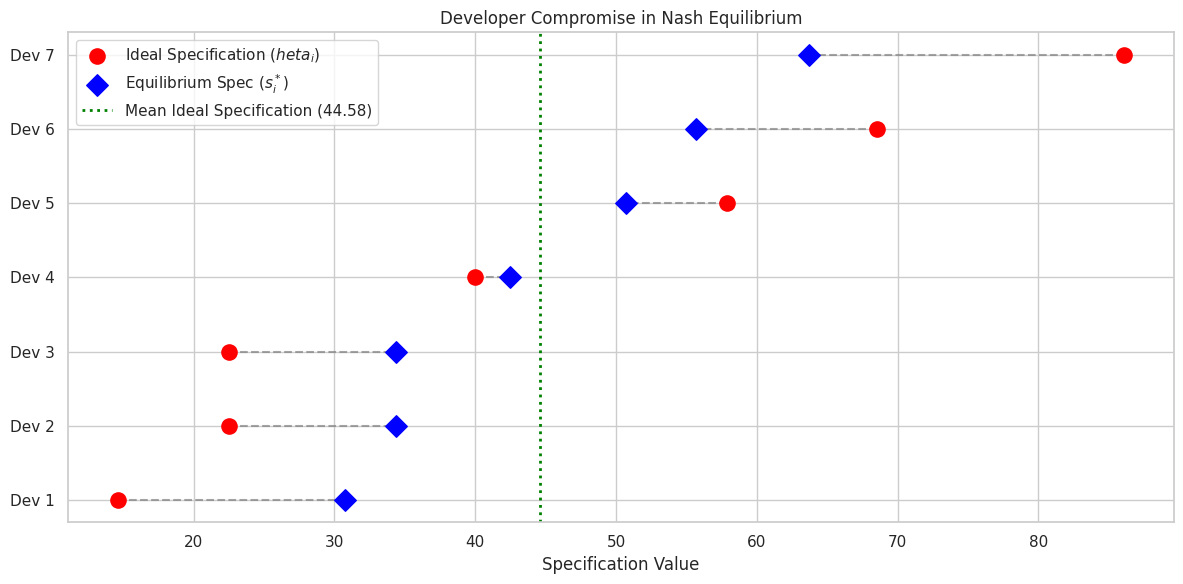

In [3]:
plt.figure(figsize=(12, 6))

# Plot lines connecting ideal to equilibrium
for i in range(n_developers):
    plt.plot([theta[i], s_star[i]], [i, i], color='gray', linestyle='--', alpha=0.7)

# Plot Ideal points
plt.scatter(theta, range(n_developers), color='red', s=120, label='Ideal Specification ($\theta_i$)', zorder=3)
# Plot Equilibrium points
plt.scatter(s_star, range(n_developers), color='blue', s=120, marker='D', label='Equilibrium Spec ($s_i^*$)', zorder=3)

# Draw overall mean line
overall_mean = np.mean(theta)
plt.axvline(overall_mean, color='green', linestyle=':', linewidth=2, label=f'Mean Ideal Specification ({overall_mean:.2f})')

plt.yticks(range(n_developers), developers)
plt.xlabel('Specification Value')
plt.title('Developer Compromise in Nash Equilibrium')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Interactive-style Analysis: Sensitivity to Group Size ($n$)
Let's see how the pull towards the average changes as the number of developers increases.

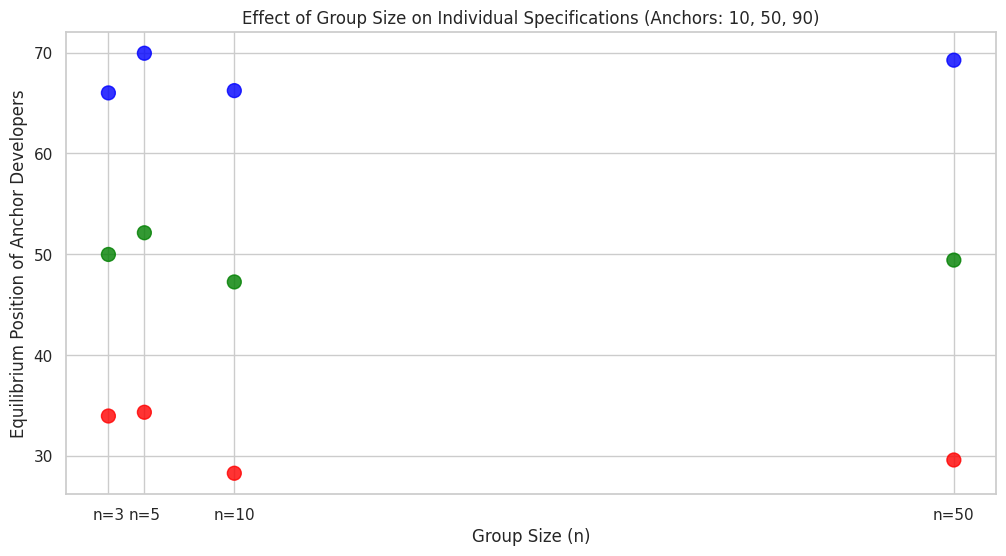

In [4]:
theta_test = np.array([10.0, 50.0, 90.0]) # 3 base developer ideals

plt.figure(figsize=(12, 6))
for n in [3, 5, 10, 50]:
    # Imagine we scale the group keeping these three reference points plus others around the mean
    if n > 3:
        rest_theta = np.random.normal(50, 15, n - 3)
        full_theta = np.concatenate([theta_test, rest_theta])
    else:
        full_theta = theta_test

    eq = compute_nash_equilibrium(full_theta)
    # Plot where the three anchor developers end up
    plt.scatter([n]*3, eq[:3], color=['red', 'green', 'blue'], s=100, alpha=0.8)

plt.xticks([3, 5, 10, 50], ['n=3', 'n=5', 'n=10', 'n=50'])
plt.xlabel('Group Size (n)')
plt.ylabel('Equilibrium Position of Anchor Developers')
plt.title('Effect of Group Size on Individual Specifications (Anchors: 10, 50, 90)')
plt.grid(True)
plt.show()

---
## References & Acknowledgement

This formulation and exercise are adapted from **Chapter 8 (Further Applications)** of the **MIT OpenCourseWare course on Game Theory**.